In [84]:
# Import dataset from Kaggles
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/                                          # specify directory
!chmod 600 ~/.kaggle/kaggle.json                                    # giving permission to read the file
!kaggle datasets download -d y0ussefkandil/bmw-sales2010-2024       # Specify author and title of dataset that is to be analysed

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/y0ussefkandil/bmw-sales2010-2024
License(s): CC0-1.0
bmw-sales2010-2024.zip: Skipping, found more recently modified local copy (use --force to force download)


In [85]:
from zipfile import ZipFile

with ZipFile("/content/bmw-sales2010-2024.zip", "r") as f:          # unzip files, 'r' for reading, 'f' for creating variable
  f.extractall("/content")                                          # path to extract into (like winrar)

# Data Manipulation

## CSV module method

In [86]:
import csv # traditional lib for reading csv files

with open("/content/BMW sales data (2010-2024).csv", newline="") as f:
   """
   No newlines to be added. Now we will make a variable to get the reader object
   """
   reader = csv.reader(f)
   # first row is the header
   header = next(reader)
   # print rows

   for i, row in enumerate(reader):
    print(row, i)                    # i lists the row number
   print(header)





Streaming output truncated to the last 5000 lines.
['M5', '2023', 'Asia', 'Silver', 'Petrol', 'Automatic', '4.6', '171644', '63655', '5369', 'Low'] 45001
['3 Series', '2017', 'Middle East', 'Silver', 'Petrol', 'Manual', '3.1', '48185', '36320', '3474', 'Low'] 45002
['5 Series', '2011', 'Europe', 'Red', 'Electric', 'Manual', '4.3', '20167', '87429', '8211', 'High'] 45003
['i8', '2014', 'South America', 'Black', 'Hybrid', 'Automatic', '4.4', '11521', '114154', '824', 'Low'] 45004
['X1', '2015', 'Middle East', 'Silver', 'Petrol', 'Automatic', '2.5', '28849', '58590', '7247', 'High'] 45005
['M5', '2017', 'Europe', 'Red', 'Electric', 'Automatic', '3.6', '161524', '51947', '7117', 'High'] 45006
['5 Series', '2012', 'North America', 'Blue', 'Electric', 'Automatic', '4.8', '62549', '91822', '9281', 'High'] 45007
['X6', '2021', 'Middle East', 'Silver', 'Petrol', 'Manual', '2.5', '894', '47506', '5077', 'Low'] 45008
['X3', '2018', 'North America', 'Grey', 'Electric', 'Manual', '3.8', '139374', '

In [87]:
# Data Manipulation
with open("/content/BMW sales data (2010-2024).csv", newline="") as f:
  reader = csv.DictReader(f)
  for row in reader:
    # we have to rememebr that this is a dictionary
    print(row["Model"])

Streaming output truncated to the last 5000 lines.
X6
M5
3 Series
5 Series
i8
X1
M5
5 Series
X6
X3
i3
3 Series
3 Series
i8
i8
M3
X5
M3
3 Series
X1
i8
X6
7 Series
5 Series
M5
5 Series
X6
i3
M5
M5
7 Series
M3
3 Series
5 Series
X6
M3
X5
X3
3 Series
X5
7 Series
7 Series
X3
i3
7 Series
X6
X5
M3
3 Series
5 Series
i3
X1
5 Series
X6
i3
i3
3 Series
3 Series
X3
X1
X5
7 Series
X1
5 Series
5 Series
i8
i8
5 Series
3 Series
X5
i3
5 Series
X6
3 Series
i8
7 Series
M3
i3
i3
5 Series
7 Series
X6
i8
3 Series
5 Series
M3
3 Series
M3
X3
3 Series
X1
X5
M3
X1
X6
X3
i8
X6
M3
X3
i8
5 Series
i3
i8
X3
5 Series
X3
3 Series
i3
X5
X6
5 Series
7 Series
i3
3 Series
X6
5 Series
i3
X6
i3
5 Series
X3
5 Series
i3
M3
X6
3 Series
X5
i3
M5
i3
X5
M3
3 Series
i3
i3
X6
M3
i8
3 Series
i3
i3
5 Series
i3
5 Series
5 Series
X5
X1
M5
7 Series
X3
7 Series
7 Series
i8
i3
3 Series
7 Series
7 Series
i8
3 Series
X1
3 Series
X1
i3
i8
M5
i8
i8
i3
X6
M5
3 Series
X6
i8
M5
X5
M5
X1
5 Series
X3
X3
i3
X1
i8
5 Series
i8
X3
3 Series
5 Series
5 Se

## Collections module method

In [88]:
# Data science time
from collections import Counter
total, count = 0, 0
with open("/content/BMW sales data (2010-2024).csv", newline="") as f:
  # store it in a dictionary
  reader = csv.DictReader(f)

  # receive a list of dictionaries
  rows = list(reader)
# Get the column values of Price_USD by reading for each rows if present
prices = [int(r ["Price_USD"]) for r in rows if r["Price_USD"]]          # if r["COLUMN"] is imp as if the column was corrupted or non existent in the csv, you would get errors
# Now for models
models = [r ["Model"] for r in rows if r["Model"]]
print(f"All cars prices: {prices}")
print(f"Minimum price for a BMV: {min(prices)}")
print(f"Maximum price for a BMV: {max(prices)}")
print(f"Most common cars: {Counter(models).most_common((3))}")


All cars prices: [98740, 79219, 113265, 60971, 49898, 42926, 55064, 102778, 116482, 96257, 117995, 74539, 100015, 119486, 34078, 94997, 114844, 81934, 111326, 82677, 88091, 62941, 49507, 101791, 47527, 85370, 116902, 107465, 32076, 64049, 102215, 64577, 53277, 118788, 116432, 108240, 52717, 37949, 86748, 35401, 69578, 37177, 60278, 96256, 82675, 118317, 79039, 86855, 112542, 93508, 119692, 49278, 44269, 46127, 100747, 96739, 57537, 46263, 65464, 54762, 93915, 117237, 34193, 89970, 65089, 86402, 44322, 111352, 50620, 44950, 101523, 31815, 118363, 43355, 84346, 66155, 101753, 68274, 78144, 87604, 90388, 102551, 117121, 68106, 78729, 71912, 94286, 50923, 37887, 101473, 96965, 76799, 119927, 72385, 63696, 35951, 95900, 44846, 95908, 119897, 55612, 72188, 89587, 46231, 85801, 92213, 42013, 50942, 83812, 93993, 30158, 102279, 36081, 93431, 40950, 66212, 90224, 49557, 100663, 83059, 45389, 36520, 40194, 82668, 107348, 52099, 117084, 38811, 109733, 53997, 101282, 87345, 64095, 117764, 40275, 3

## Pandas Method

In [89]:
# Data Manip with pandas method
import pandas as pd

In [90]:
# series - has an index and value to it
s = pd.Series([10,20,30], index=["a", "b", "c"])
# length of values/lists must match index no. amount
print(s)

a    10
b    20
c    30
dtype: int64


In [91]:
s.info()                #.info prints a summary of the series

<class 'pandas.core.series.Series'>
Index: 3 entries, a to c
Series name: None
Non-Null Count  Dtype
--------------  -----
3 non-null      int64
dtypes: int64(1)
memory usage: 48.0+ bytes


In [92]:
df = pd.read_csv("/content/BMW sales data (2010-2024).csv")
df.head()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [93]:
df.info()
"""
non null count index can be useful in identifying corrupt data rows.
Also check memory usage, particularly when dealing with neural networks.
"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


'\nnon null count index can be useful in identifying corrupt data rows. \nAlso check memory usage, particularly when dealing with neural networks.\n'

In [94]:
df["Model"].head()

,Model
0,5 Series
1,i8
2,5 Series
3,X3
4,7 Series


In [95]:
df[["Model", "Year"]].head()

,Model,Year
0,5 Series,2016
1,i8,2013
2,5 Series,2022
3,X3,2024
4,7 Series,2020


In [96]:
# iloc - index location
# loc  - location name
df.iloc[0,[1,2,3]]           # 1st no. is the row index, next are the columns that are added

,0
Year,2016
Region,Asia
Color,Red


In [97]:
df.loc[0, "Model"]

'5 Series'

In [98]:
# To get data on every car newer than 2022
#print(df[df["Year"] > 2022])

# To get cars that are from range 2022-2023 AND sort by price
cars = df[(df["Year"] >= 2022) & (df["Year"] <= 2023)]
cars.sort_values(by="Price_USD", ascending=False)
cars.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
25,X3,2023,Middle East,White,Electric,Automatic,4.1,194398,85370,4645,Low
34,X1,2022,Middle East,Grey,Hybrid,Manual,4.3,143013,116432,4926,Low
45,i8,2023,Europe,Blue,Diesel,Automatic,3.8,78573,118317,7168,High


6646 tell us how many cars were made after 2022

<Axes: >

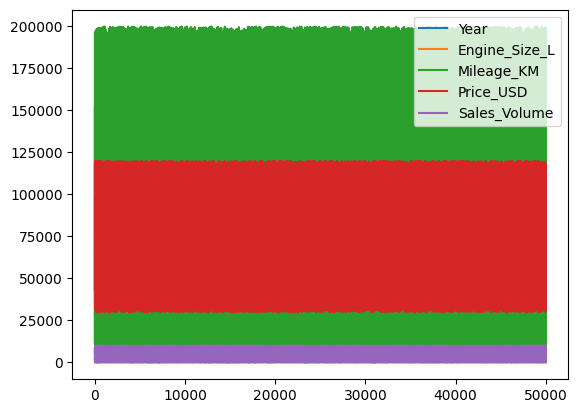

In [99]:
# observe data
df.plot(kind="line")
# pandas does not plot strings


<Axes: xlabel='Model', ylabel='Average Sales'>

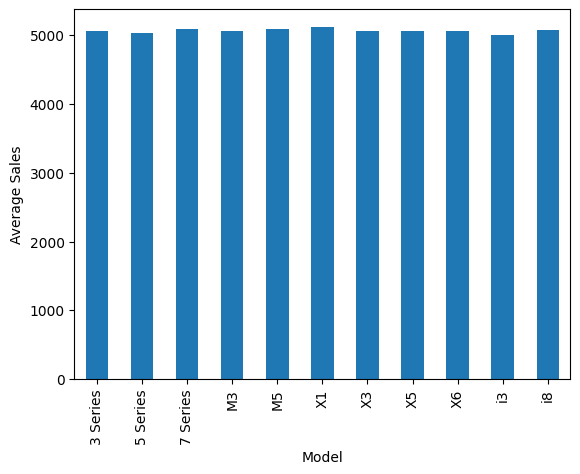

In [100]:
df.groupby("Model")["Sales_Volume"].mean().plot(kind="bar", ylabel="Average Sales")



# Are higher budget movies better rated?


In [101]:
!kaggle datasets download -d ashpalsingh1525/imdb-movies-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/ashpalsingh1525/imdb-movies-dataset
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 2.84M/2.84M [00:00<00:00, 184MB/s]



In [102]:
movies_dataset = pd.read_csv("/content/imdb_movies.csv")
movies_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [103]:
# Data Preprocessing/Cleaning

movies_dataset.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [104]:
# filtering
filtered = movies_dataset[["names", "score", "budget_x"]]
filtered.head()

,names,score,budget_x
0,Creed III,73.0,75000000.0
1,Avatar: The Way of Water,78.0,460000000.0
2,The Super Mario Bros. Movie,76.0,100000000.0
3,Mummies,70.0,12300000.0
4,Supercell,61.0,77000000.0


In [105]:
min_score = filtered["score"].min()
max_score = filtered["score"].max()

# Get the movies
worst_movies = filtered[filtered["score"] == min_score]
best_movies = filtered[filtered["score"] == max_score]

print(worst_movies[["names", "score", "budget_x"]])
print(best_movies[["names", "score", "budget_x"]])

                                                   names  score     budget_x
117                                               Fast X    0.0  340000000.0
216                                   The Little Mermaid    0.0  205000000.0
229                     Transformers: Rise of the Beasts    0.0  200000000.0
231                  Spider-Man: Across the Spider-Verse    0.0  264940000.0
305                     Housewife Sex Slaves: Hatano Yui    0.0  167540000.0
...                                                  ...    ...          ...
9747                     Step Up Love Story: Double Love    0.0  264940000.0
9769                                              Dinner    0.0  170000000.0
9776                                   Delicious Sisters    0.0  181600000.0
9877   Detective Conan: Haibara Ai Monogatari ~Kuroga...    0.0  131600000.0
10087                                       DADDY OWL!!!    0.0          1.0

[211 rows x 3 columns]
                                        names  score

In [106]:
# indentify the row with a supposed hallucination
worst_movies.drop(10087)

,names,score,budget_x
117,Fast X,0.0,340000000.0
216,The Little Mermaid,0.0,205000000.0
229,Transformers: Rise of the Beasts,0.0,200000000.0
231,Spider-Man: Across the Spider-Verse,0.0,264940000.0
305,Housewife Sex Slaves: Hatano Yui,0.0,167540000.0
...,...,...,...
9733,Fanatic,0.0,167540000.0
9747,Step Up Love Story: Double Love,0.0,264940000.0
9769,Dinner,0.0,170000000.0
9776,Delicious Sisters,0.0,181600000.0


/tmp/ipykernel_3879/211961872.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="budget_x", y ="score",


<function matplotlib.pyplot.show(close=None, block=None)>

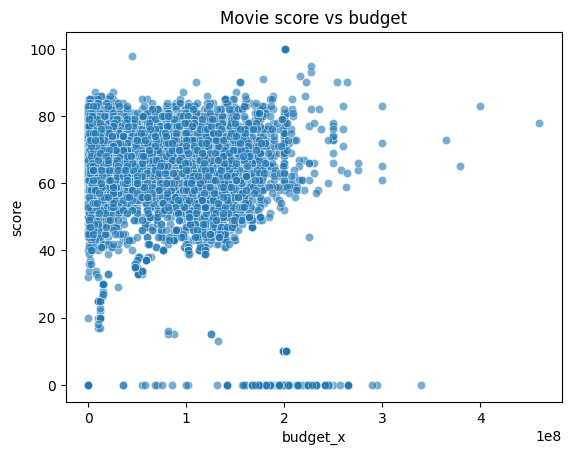

In [107]:
import seaborn as sns

sns.scatterplot(x="budget_x", y ="score",
    palette="crest",
    data=filtered,
    alpha=0.6)

plt.title('Movie score vs budget')
plt.show

Random values that stray add to the noise, worsening the correlation coefficient

In [108]:
# Highlight correlation between budget and score
corr = filtered["budget_x"].corr(filtered["score"])
print(f"Correlation between budget and score: {corr}")

# negative correlation is bad

Correlation between budget and score: -0.23547009911115632


/tmp/ipykernel_3879/2668231286.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="budget_x", y ="score",


Text(0.5, 1.0, 'Movie Score vs Budget with a Gradiant')

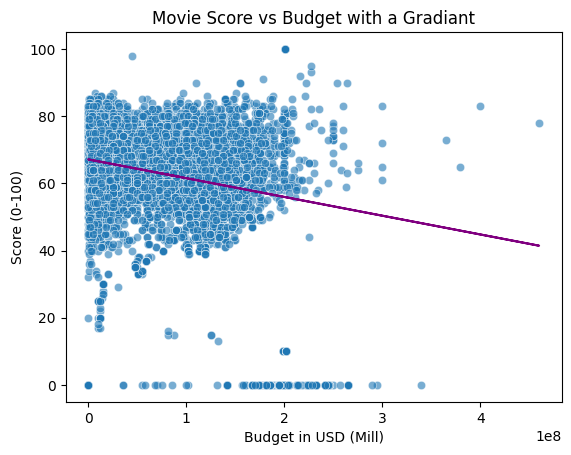

In [109]:
# Linear fitting required for the plotting of a trend line/gradient
import numpy as np
import matplotlib.pyplot as plt

x = filtered["budget_x"]
y = filtered["score"]

m, b = np.polyfit(x, y, 1)
sns.scatterplot(x="budget_x", y ="score",
    palette="crest",
    data=filtered,
    alpha=0.6)
plt.plot(x, m*x+b, color = "purple")
plt.xlabel("Budget in USD (Mill)")
plt.ylabel("Score (0-100)")
plt.title("Movie Score vs Budget with a Gradiant")